# 3.5 Mixture Models: Cell Type Discovery with Gaussian Mixture Models

This notebook demonstrates **Gaussian Mixture Models (GMM)** for unsupervised cell type discovery in single-cell RNA sequencing (scRNA-seq). We'll identify hidden cell populations in brain tissue based on gene expression patterns, without using any predefined labels.

## Real-World Scenario

A neuroscience lab has performed scRNA-seq on a dissected mouse cortex sample to:
- **Identify cell types** present in the tissue without prior labeling
- **Quantify cell type proportions** for tissue composition analysis
- **Flag ambiguous cells** that may be doublets or transitional states

After standard preprocessing and dimensionality reduction (normalization, PCA), each cell is represented by its coordinates along the first two principal components (PC1, PC2).

The challenge: We don't know how many cell types are present or what defines them. GMM will **discover these populations automatically**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import multivariate_normal
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## 1. Understanding Mixture Models

### The Core Idea

A **mixture model** assumes that data comes from multiple underlying populations (components), each with its own distribution. The overall probability density is:

$$p(\mathbf{y}|\boldsymbol{\theta}) = \sum_{k=1}^{K} \pi_k \, p_k(\mathbf{y})$$

where:
- $K$ = number of mixture components (cell types)
- $\pi_k$ = **mixing weight** for component $k$ (probability a random cell belongs to type $k$)
- $p_k(\mathbf{y})$ = probability density of component $k$
- Constraint: $\sum_{k=1}^K \pi_k = 1$ and $\pi_k \geq 0$

### Gaussian Mixture Model (GMM)

When each component is a multivariate Gaussian:

$$p(\mathbf{y}|\boldsymbol{\theta}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{y}|\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

The parameters are:
- $\boldsymbol{\mu}_k$ = mean vector of component $k$ (center of the cluster in PC space)
- $\boldsymbol{\Sigma}_k$ = covariance matrix of component $k$ (shape and spread of the population)
- $\pi_k$ = mixing weight (relative abundance of the cell type)

## 2. Generate Synthetic scRNA-seq Data

Let's create realistic single-cell data with **three hidden cell types** in mouse cortex:

1. **Excitatory Neurons**: The most abundant cortical cell type, high PC1 (driven by synaptic genes like *Snap25*, *Slc17a7*)
2. **Astrocytes**: Glial support cells, high PC2 (driven by glial markers like *Gfap*, *Aqp4*)
3. **Oligodendrocytes**: Myelinating cells, distinct PC signature (driven by *Mbp*, *Plp1*)

In [2]:
# True parameters (unknown to our algorithm)
true_K = 3

# Cell type 1: Excitatory Neurons — high PC1, moderate PC2
mu1 = np.array([6.0, 1.5])
Sigma1 = np.array([[1.8, 0.4],
                   [0.4, 0.9]])

# Cell type 2: Astrocytes — low PC1, high PC2
mu2 = np.array([1.0, 6.5])
Sigma2 = np.array([[1.2, -0.3],
                   [-0.3, 1.5]])

# Cell type 3: Oligodendrocytes — moderate PC1, low PC2
mu3 = np.array([-3.0, -1.0])
Sigma3 = np.array([[2.0, 0.6],
                   [0.6, 1.0]])

# True mixing weights (cell type proportions in cortex)
true_pi = np.array([0.50, 0.30, 0.20])  # 50% neurons, 30% astrocytes, 20% oligos

# Generate samples (one cell = one data point)
N = 500
n1 = int(N * true_pi[0])
n2 = int(N * true_pi[1])
n3 = N - n1 - n2

Y1 = np.random.multivariate_normal(mu1, Sigma1, n1)
Y2 = np.random.multivariate_normal(mu2, Sigma2, n2)
Y3 = np.random.multivariate_normal(mu3, Sigma3, n3)

# Combine all data (lose cell type labels)
Y = np.vstack([Y1, Y2, Y3])
np.random.shuffle(Y)  # Shuffle to mix populations

# True labels for visualization (not used in training)
true_labels = np.concatenate([np.zeros(n1), np.ones(n2), 2*np.ones(n3)])

print(f"Generated {N} single cells")
print(f"Features: PC1 and PC2 from PCA on normalized gene expression")

Generated 500 single cells
Features: PC1 and PC2 from PCA on normalized gene expression


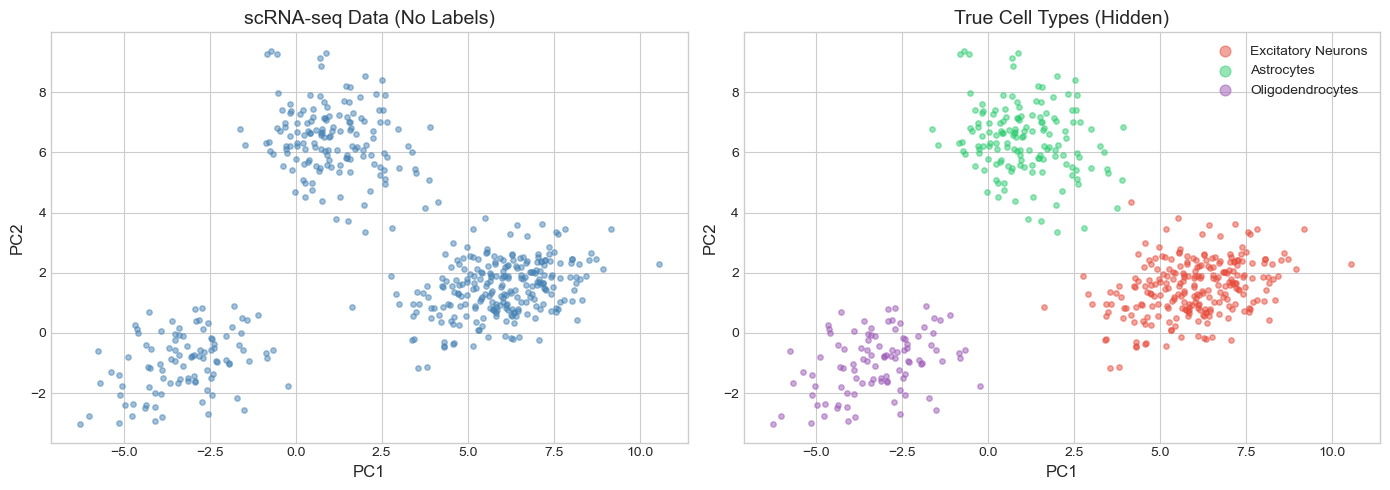

Left: What the researcher observes — unlabeled cells in PC space
Right: The hidden truth — can GMM discover these cell types?


In [3]:
# Visualize the raw data (what the researcher sees)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw data without labels
axes[0].scatter(Y[:, 0], Y[:, 1], alpha=0.5, s=15, c='steelblue')
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].set_title('scRNA-seq Data (No Labels)', fontsize=14)

# Right: True cell types (hidden truth)
colors = ['#e74c3c', '#2ecc71', '#9b59b6']
celltype_names = ['Excitatory Neurons', 'Astrocytes', 'Oligodendrocytes']
data_segments = [Y1, Y2, Y3]

for i, (data, name, color) in enumerate(zip(data_segments, celltype_names, colors)):
    axes[1].scatter(data[:, 0], data[:, 1], alpha=0.5, s=15, c=color, label=name)

axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('True Cell Types (Hidden)', fontsize=14)
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.show()

print("Left: What the researcher observes — unlabeled cells in PC space")
print("Right: The hidden truth — can GMM discover these cell types?")

## 3. The Latent Variable Perspective

### Hierarchical Model Interpretation

We can think of GMM as a **two-step generative process**:

1. **Sample the cell type**: $z \sim \text{Cat}(\boldsymbol{\pi})$ where $p(z=k) = \pi_k$
2. **Sample the expression profile**: $\mathbf{y} | z=k \sim \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$

The latent variable $z$ indicates which cell type generated each observation. By marginalizing out $z$:

$$p(\mathbf{y}|\boldsymbol{\theta}) = \sum_{k=1}^{K} p(z=k|\boldsymbol{\theta}) \, p(\mathbf{y}|z=k, \boldsymbol{\theta}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{y}|\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

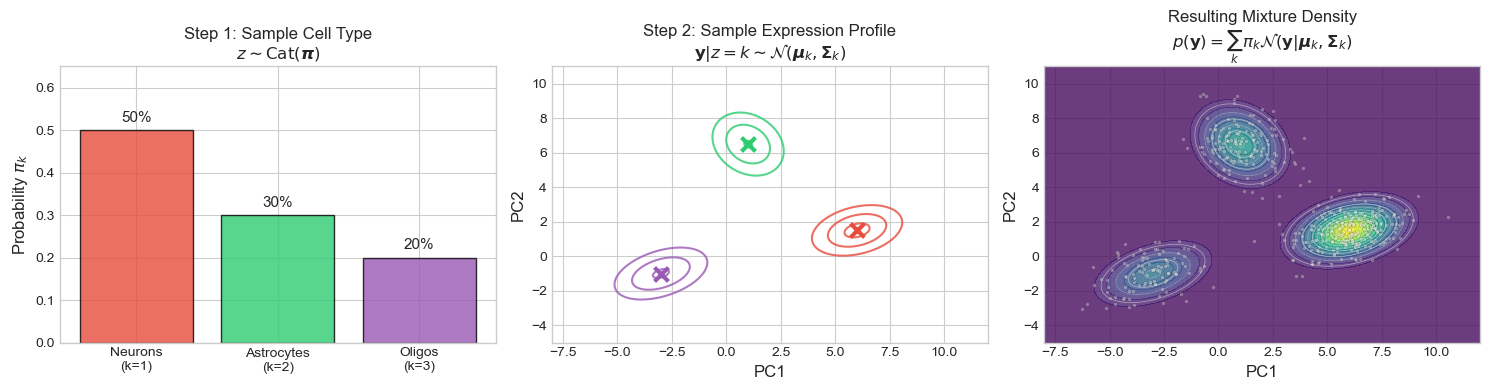

In [4]:
# Visualize the generative model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Step 1: Prior over cell types
celltypes = ['Neurons\n(k=1)', 'Astrocytes\n(k=2)', 'Oligos\n(k=3)']
bars = axes[0].bar(celltypes, true_pi, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Probability $\pi_k$', fontsize=12)
axes[0].set_title('Step 1: Sample Cell Type\n$z \\sim \\mathrm{Cat}(\\boldsymbol{\\pi})$', fontsize=12)
axes[0].set_ylim(0, 0.65)
for bar, val in zip(bars, true_pi):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.0%}', ha='center', fontsize=11)

# Step 2: Sample from component
x = np.linspace(-8, 12, 200)
y_range = np.linspace(-5, 11, 200)
X_grid, Y_grid = np.meshgrid(x, y_range)
pos = np.dstack((X_grid, Y_grid))

mus = [mu1, mu2, mu3]
Sigmas = [Sigma1, Sigma2, Sigma3]

for i, (mu, Sigma, color, name) in enumerate(zip(mus, Sigmas, colors, celltype_names)):
    rv = multivariate_normal(mu, Sigma)
    axes[1].contour(X_grid, Y_grid, rv.pdf(pos), levels=3, colors=[color], alpha=0.8)
    axes[1].scatter(*mu, c=color, s=100, marker='x', linewidths=3)

axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('Step 2: Sample Expression Profile\n$\\mathbf{y}|z=k \\sim \\mathcal{N}(\\boldsymbol{\\mu}_k, \\boldsymbol{\\Sigma}_k)$', fontsize=12)

# Step 3: Resulting mixture
mixture_pdf = np.zeros_like(X_grid)
for pi, mu, Sigma in zip(true_pi, mus, Sigmas):
    rv = multivariate_normal(mu, Sigma)
    mixture_pdf += pi * rv.pdf(pos)

axes[2].contourf(X_grid, Y_grid, mixture_pdf, levels=20, cmap='viridis', alpha=0.8)
axes[2].contour(X_grid, Y_grid, mixture_pdf, levels=10, colors='white', alpha=0.5, linewidths=0.5)
axes[2].scatter(Y[:, 0], Y[:, 1], alpha=0.3, s=8, c='white', edgecolors='black', linewidths=0.3)
axes[2].set_xlabel('PC1', fontsize=12)
axes[2].set_ylabel('PC2', fontsize=12)
axes[2].set_title('Resulting Mixture Density\n$p(\\mathbf{y}) = \\sum_k \\pi_k \\mathcal{N}(\\mathbf{y}|\\boldsymbol{\\mu}_k, \\boldsymbol{\\Sigma}_k)$', fontsize=12)

plt.tight_layout()
plt.show()

## 4. Computing Responsibilities (Soft Clustering)

### The Key Question: Which Cell Type Does Each Cell Belong To?

Given observed data $\mathbf{y}_n$ and model parameters $\boldsymbol{\theta}$, we compute the **posterior probability** that cell $n$ belongs to type $k$:

$$r_{nk} \triangleq p(z_n = k | \mathbf{y}_n, \boldsymbol{\theta}) = \frac{p(z_n=k|\boldsymbol{\theta}) \, p(\mathbf{y}_n|z_n=k, \boldsymbol{\theta})}{\sum_{k'=1}^{K} p(z_n=k'|\boldsymbol{\theta}) \, p(\mathbf{y}_n|z_n=k', \boldsymbol{\theta})}$$

Substituting our GMM:

$$r_{nk} = \frac{\pi_k \, \mathcal{N}(\mathbf{y}_n|\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{k'=1}^{K} \pi_{k'} \, \mathcal{N}(\mathbf{y}_n|\boldsymbol{\mu}_{k'}, \boldsymbol{\Sigma}_{k'})}$$

The $r_{nk}$ are called **responsibilities** because they tell us how "responsible" each component is for generating each data point.

In [5]:
def compute_responsibilities(Y, pi, mus, Sigmas):
    """
    Compute responsibilities r_nk = p(z_n = k | y_n, theta)
    
    Parameters:
    -----------
    Y : (N, D) array - data points
    pi : (K,) array - mixing weights
    mus : list of (D,) arrays - component means
    Sigmas : list of (D, D) arrays - component covariances
    
    Returns:
    --------
    R : (N, K) array - responsibilities
    """
    N = Y.shape[0]
    K = len(pi)
    
    # Compute weighted likelihoods: pi_k * N(y_n | mu_k, Sigma_k)
    weighted_likelihoods = np.zeros((N, K))
    for k in range(K):
        rv = multivariate_normal(mus[k], Sigmas[k])
        weighted_likelihoods[:, k] = pi[k] * rv.pdf(Y)
    
    # Normalize to get responsibilities
    total = weighted_likelihoods.sum(axis=1, keepdims=True)
    R = weighted_likelihoods / total
    
    return R

# Compute responsibilities using true parameters
R_true = compute_responsibilities(Y, true_pi, mus, Sigmas)

print("Responsibilities for first 5 cells:")
print("Cell | Neuron | Astrocyte | Oligo | Most Likely Type")
print("-" * 60)
for i in range(5):
    best_k = np.argmax(R_true[i])
    print(f" {i+1:3d} | {R_true[i,0]:6.1%} |  {R_true[i,1]:6.1%}  | {R_true[i,2]:5.1%} | {celltype_names[best_k]}")

Responsibilities for first 5 cells:
Cell | Neuron | Astrocyte | Oligo | Most Likely Type
------------------------------------------------------------
   1 |   0.0% |  100.0%  |  0.0% | Astrocytes
   2 |   0.0% |  100.0%  |  0.0% | Astrocytes
   3 | 100.0% |    0.0%  |  0.0% | Excitatory Neurons
   4 | 100.0% |    0.0%  |  0.0% | Excitatory Neurons
   5 |   0.0% |  100.0%  |  0.0% | Astrocytes


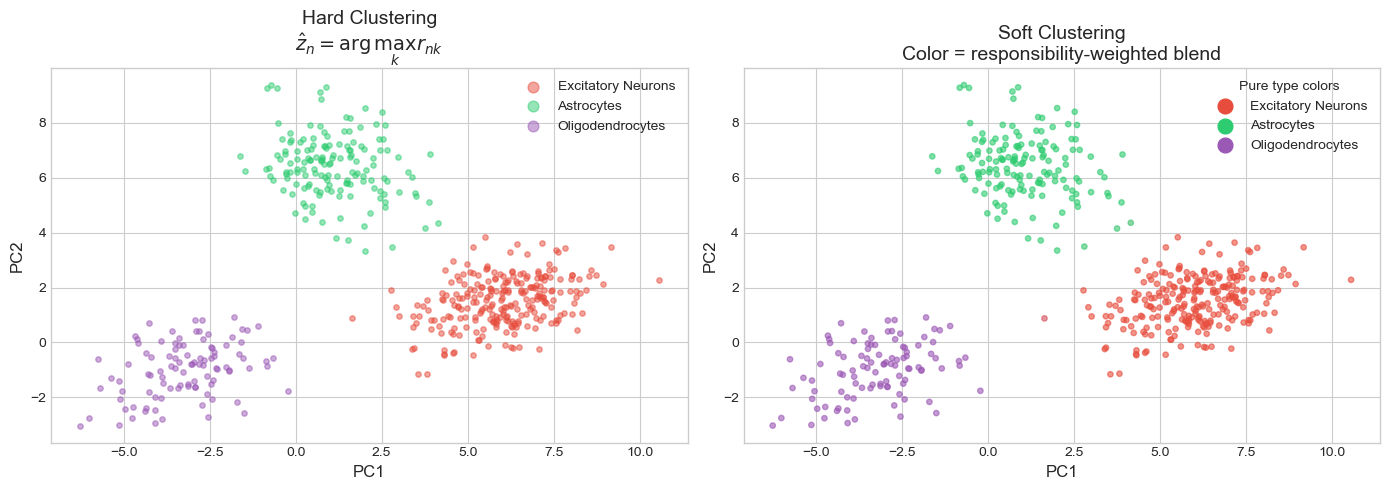


Soft clustering preserves uncertainty — mixed colors indicate cells
that could plausibly belong to multiple types (e.g., doublets or transitional states).


In [6]:
# Visualize soft vs hard clustering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hard clustering: assign to most likely cell type
hard_labels = np.argmax(R_true, axis=1)

# Left: Hard clustering
for k in range(3):
    mask = hard_labels == k
    axes[0].scatter(Y[mask, 0], Y[mask, 1], c=colors[k], alpha=0.5, s=15, label=celltype_names[k])
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].set_title('Hard Clustering\n$\hat{z}_n = \\arg\\max_k r_{nk}$', fontsize=14)
axes[0].legend(markerscale=2)

# Right: Soft clustering (color by responsibility blend)
# RGB color based on responsibilities
rgb_colors_base = np.array([[0.91, 0.30, 0.24],   # Red for neurons
                            [0.18, 0.80, 0.44],   # Green for astrocytes
                            [0.61, 0.35, 0.71]])  # Purple for oligodendrocytes

point_colors = R_true @ rgb_colors_base
axes[1].scatter(Y[:, 0], Y[:, 1], c=point_colors, alpha=0.6, s=15)
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('Soft Clustering\nColor = responsibility-weighted blend', fontsize=14)

# Add legend for soft clustering
for k, (color, name) in enumerate(zip(colors, celltype_names)):
    axes[1].scatter([], [], c=color, s=50, label=name)
axes[1].legend(title='Pure type colors', markerscale=1.5)

plt.tight_layout()
plt.show()

print("\nSoft clustering preserves uncertainty — mixed colors indicate cells")
print("that could plausibly belong to multiple types (e.g., doublets or transitional states).")

## 5. The EM Algorithm for GMM

In practice, we don't know the true parameters $\boldsymbol{\theta} = (\pi_1, ..., \pi_K, \boldsymbol{\mu}_1, ..., \boldsymbol{\mu}_K, \boldsymbol{\Sigma}_1, ..., \boldsymbol{\Sigma}_K)$. 

The **Expectation-Maximization (EM) algorithm** iteratively estimates them:

### E-Step (Expectation)
Compute responsibilities using current parameters:
$$r_{nk}^{(t)} = \frac{\pi_k^{(t)} \, \mathcal{N}(\mathbf{y}_n|\boldsymbol{\mu}_k^{(t)}, \boldsymbol{\Sigma}_k^{(t)})}{\sum_{k'} \pi_{k'}^{(t)} \, \mathcal{N}(\mathbf{y}_n|\boldsymbol{\mu}_{k'}^{(t)}, \boldsymbol{\Sigma}_{k'}^{(t)})}$$

### M-Step (Maximization)
Update parameters using responsibilities:

**Effective number of cells in cluster $k$:**
$$N_k = \sum_{n=1}^{N} r_{nk}$$

**Updated mixing weights (cell type proportions):**
$$\pi_k^{(t+1)} = \frac{N_k}{N}$$

**Updated means (responsibility-weighted average):**
$$\boldsymbol{\mu}_k^{(t+1)} = \frac{1}{N_k} \sum_{n=1}^{N} r_{nk} \, \mathbf{y}_n$$

**Updated covariances:**
$$\boldsymbol{\Sigma}_k^{(t+1)} = \frac{1}{N_k} \sum_{n=1}^{N} r_{nk} \, (\mathbf{y}_n - \boldsymbol{\mu}_k^{(t+1)})(\mathbf{y}_n - \boldsymbol{\mu}_k^{(t+1)})^T$$

In [7]:
def gmm_em(Y, K, max_iter=100, tol=1e-6, verbose=True):
    """
    Fit a Gaussian Mixture Model using EM algorithm.
    
    Parameters:
    -----------
    Y : (N, D) array - data points
    K : int - number of components
    max_iter : int - maximum iterations
    tol : float - convergence tolerance on log-likelihood
    
    Returns:
    --------
    pi, mus, Sigmas, R, log_likelihoods, history
    """
    N, D = Y.shape
    
    # Initialize parameters using k-means++ style
    # Pick first center randomly
    idx = [np.random.randint(N)]
    for _ in range(K - 1):
        # Compute distances to nearest center
        dists = np.min([np.sum((Y - Y[i])**2, axis=1) for i in idx], axis=0)
        probs = dists / dists.sum()
        idx.append(np.random.choice(N, p=probs))
    
    mus = [Y[i].copy() for i in idx]
    Sigmas = [np.cov(Y.T) + 0.1*np.eye(D) for _ in range(K)]  # Start with data covariance
    pi = np.ones(K) / K
    
    log_likelihoods = []
    history = []  # Store parameter history for visualization
    
    for iteration in range(max_iter):
        # Store current state
        history.append({
            'pi': pi.copy(),
            'mus': [mu.copy() for mu in mus],
            'Sigmas': [Sigma.copy() for Sigma in Sigmas]
        })
        
        # E-Step: Compute responsibilities
        weighted_likelihoods = np.zeros((N, K))
        for k in range(K):
            try:
                rv = multivariate_normal(mus[k], Sigmas[k])
                weighted_likelihoods[:, k] = pi[k] * rv.pdf(Y)
            except:
                # Add regularization if covariance becomes singular
                Sigmas[k] += 0.01 * np.eye(D)
                rv = multivariate_normal(mus[k], Sigmas[k])
                weighted_likelihoods[:, k] = pi[k] * rv.pdf(Y)
        
        total_likelihood = weighted_likelihoods.sum(axis=1)
        R = weighted_likelihoods / total_likelihood[:, np.newaxis]
        
        # Compute log-likelihood
        ll = np.sum(np.log(total_likelihood + 1e-10))
        log_likelihoods.append(ll)
        
        if verbose and iteration % 10 == 0:
            print(f"Iteration {iteration:3d}: Log-likelihood = {ll:.2f}")
        
        # Check convergence
        if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            if verbose:
                print(f"Converged at iteration {iteration}")
            break
        
        # M-Step: Update parameters
        N_k = R.sum(axis=0)  # Effective number of points per cluster
        
        for k in range(K):
            # Update mixing weights
            pi[k] = N_k[k] / N
            
            # Update means
            mus[k] = (R[:, k:k+1].T @ Y).flatten() / N_k[k]
            
            # Update covariances
            diff = Y - mus[k]
            Sigmas[k] = (R[:, k:k+1] * diff).T @ diff / N_k[k]
            # Add small regularization for numerical stability
            Sigmas[k] += 1e-6 * np.eye(D)
    
    return pi, mus, Sigmas, R, log_likelihoods, history

In [8]:
# Fit GMM to our scRNA-seq data
print("Fitting GMM with K=3 components...\n")
pi_est, mus_est, Sigmas_est, R_est, lls, history = gmm_em(Y, K=3, max_iter=100)

print("\n" + "="*60)
print("ESTIMATED PARAMETERS")
print("="*60)

# Sort components by PC1 coordinate for consistent ordering
order = np.argsort([mu[0] for mu in mus_est])

# Map: lowest PC1 → oligos, mid → astrocytes, highest → neurons
est_names = ['Oligodendrocytes', 'Astrocytes', 'Excitatory Neurons']

for i, k in enumerate(order):
    print(f"\nComponent {i+1} (estimated as {est_names[i]}):")
    print(f"  Mixing weight: {pi_est[k]:.1%}")
    print(f"  Mean PC1: {mus_est[k][0]:.2f}")
    print(f"  Mean PC2: {mus_est[k][1]:.2f}")

Fitting GMM with K=3 components...

Iteration   0: Log-likelihood = -2706.48
Converged at iteration 8

ESTIMATED PARAMETERS

Component 1 (estimated as Oligodendrocytes):
  Mixing weight: 20.0%
  Mean PC1: -3.22
  Mean PC2: -0.98

Component 2 (estimated as Astrocytes):
  Mixing weight: 30.2%
  Mean PC1: 1.08
  Mean PC2: 6.41

Component 3 (estimated as Excitatory Neurons):
  Mixing weight: 49.8%
  Mean PC1: 6.00
  Mean PC2: 1.50


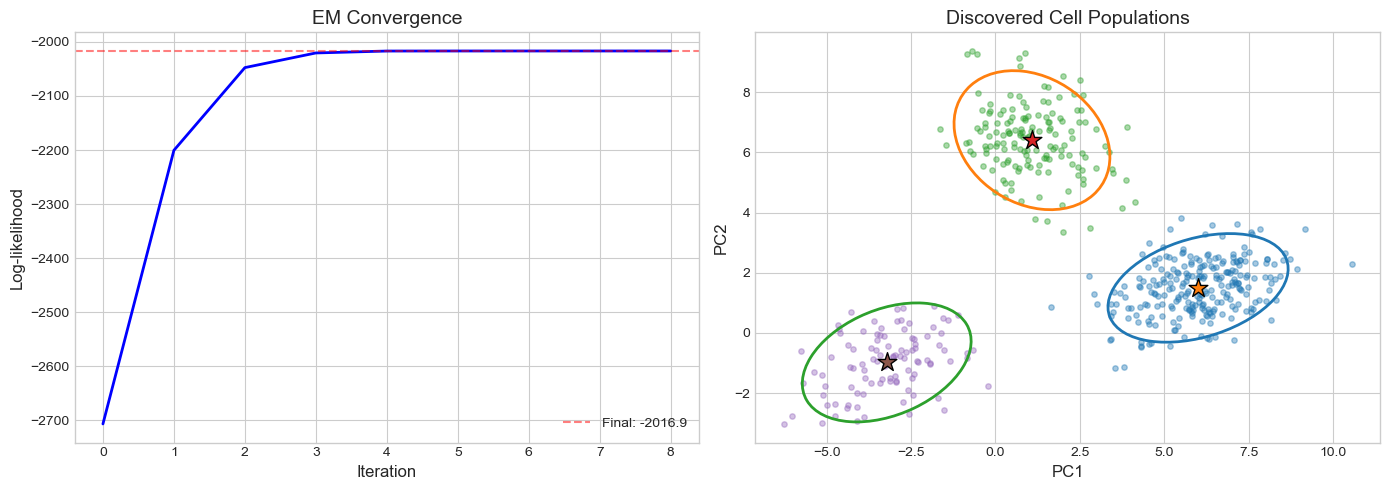

In [9]:
# Visualize EM convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Log-likelihood over iterations
axes[0].plot(lls, 'b-', linewidth=2)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Log-likelihood', fontsize=12)
axes[0].set_title('EM Convergence', fontsize=14)
axes[0].axhline(y=lls[-1], color='r', linestyle='--', alpha=0.5, label=f'Final: {lls[-1]:.1f}')
axes[0].legend()

# Right: Final clustering result
hard_labels_est = np.argmax(R_est, axis=1)

def plot_ellipse(ax, mean, cov, color, n_std=2.0):
    """Plot covariance ellipse"""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order_eig = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order_eig], eigenvectors[:, order_eig]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      facecolor='none', edgecolor=color, linewidth=2)
    ax.add_patch(ellipse)

for k in range(3):
    mask = hard_labels_est == k
    axes[1].scatter(Y[mask, 0], Y[mask, 1], alpha=0.4, s=15)
    axes[1].scatter(*mus_est[k], s=200, marker='*', edgecolors='black', linewidths=1)
    plot_ellipse(axes[1], mus_est[k], Sigmas_est[k], plt.cm.tab10(k))

axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('Discovered Cell Populations', fontsize=14)

plt.tight_layout()
plt.show()

## 6. Visualizing the EM Algorithm Step by Step

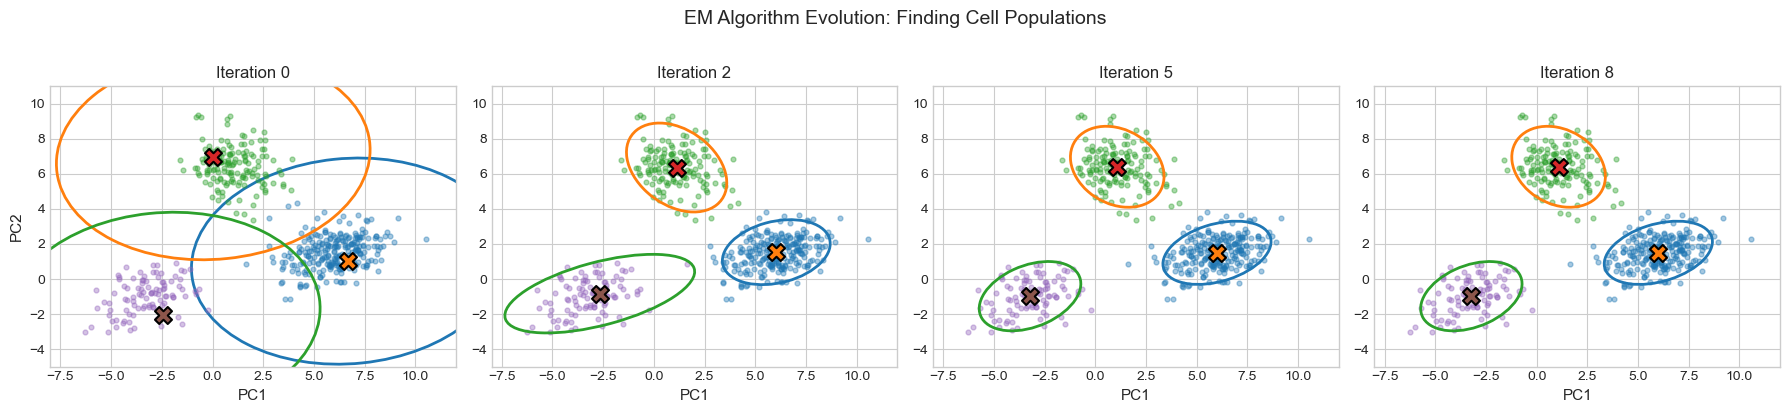

In [10]:
# Show EM evolution
iterations_to_show = [0, 2, 5, len(history)-1]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax_idx, iter_idx in enumerate(iterations_to_show):
    ax = axes[ax_idx]
    params = history[iter_idx]
    
    # Compute responsibilities for this iteration
    R_iter = compute_responsibilities(Y, params['pi'], params['mus'], params['Sigmas'])
    labels_iter = np.argmax(R_iter, axis=1)
    
    for k in range(3):
        mask = labels_iter == k
        ax.scatter(Y[mask, 0], Y[mask, 1], alpha=0.4, s=12)
        ax.scatter(*params['mus'][k], s=150, marker='X', edgecolors='black', linewidths=1.5)
        try:
            plot_ellipse(ax, params['mus'][k], params['Sigmas'][k], plt.cm.tab10(k))
        except:
            pass
    
    ax.set_xlim(-8, 12)
    ax.set_ylim(-5, 11)
    ax.set_title(f'Iteration {iter_idx}', fontsize=12)
    if ax_idx == 0:
        ax.set_ylabel('PC2', fontsize=11)
    ax.set_xlabel('PC1', fontsize=11)

plt.suptitle('EM Algorithm Evolution: Finding Cell Populations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Biological Insights from Cell Type Discovery

Let's analyze the discovered cell populations and derive insights about tissue composition.

In [11]:
# Assign cells to types
segment_assignment = np.argmax(R_est, axis=1)

# Reorder by PC1 for consistent mapping
order = np.argsort([mus_est[k][0] for k in range(3)])
type_names_ordered = ['Oligodendrocytes', 'Astrocytes', 'Excitatory Neurons']

print("="*70)
print("CELL TYPE COMPOSITION ANALYSIS")
print("="*70)

for i, k in enumerate(order):
    mask = segment_assignment == k
    n_cells = mask.sum()
    mean_pc1 = Y[mask, 0].mean()
    mean_pc2 = Y[mask, 1].mean()
    
    print(f"\n{type_names_ordered[i].upper()}")
    print(f"  Cells: {n_cells} ({n_cells/N:.1%} of total)")
    print(f"  Mean PC1: {mean_pc1:.2f}  |  Mean PC2: {mean_pc2:.2f}")
    print(f"  Estimated proportion (pi_k): {pi_est[k]:.1%}")

print("\n" + "="*70)

CELL TYPE COMPOSITION ANALYSIS

OLIGODENDROCYTES
  Cells: 100 (20.0% of total)
  Mean PC1: -3.22  |  Mean PC2: -0.98
  Estimated proportion (pi_k): 20.0%

ASTROCYTES
  Cells: 151 (30.2% of total)
  Mean PC1: 1.08  |  Mean PC2: 6.41
  Estimated proportion (pi_k): 30.2%

EXCITATORY NEURONS
  Cells: 249 (49.8% of total)
  Mean PC1: 6.00  |  Mean PC2: 1.50
  Estimated proportion (pi_k): 49.8%



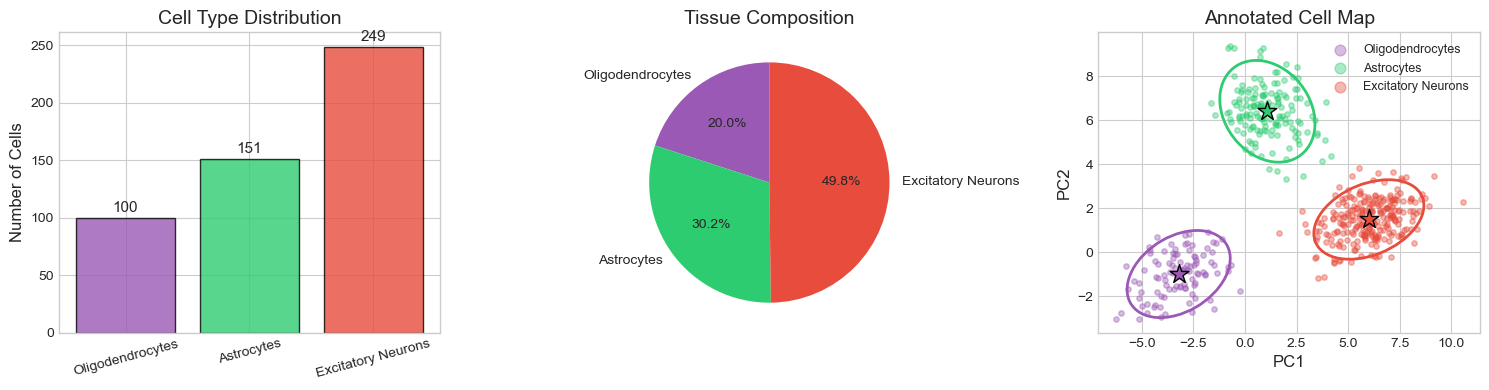


Key insight: The estimated proportions (~50% neurons, ~30% astrocytes, ~20% oligos)
are consistent with known mouse cortex composition from the literature.


In [12]:
# Biological visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Recompute stats for visualization
n_per_type = []
for k in order:
    mask = segment_assignment == k
    n_per_type.append(mask.sum())

# Cell type distribution
bars = axes[0].bar(type_names_ordered, n_per_type, color=colors[::-1], edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Number of Cells', fontsize=12)
axes[0].set_title('Cell Type Distribution', fontsize=14)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, n_per_type):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 str(val), ha='center', fontsize=11)

# Proportions as pie chart
proportions = [pi_est[k] for k in order]
axes[1].pie(proportions, labels=type_names_ordered, colors=colors[::-1],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Tissue Composition', fontsize=14)

# PC1 vs PC2 with annotated clusters
for i, k in enumerate(order):
    mask = segment_assignment == k
    axes[2].scatter(Y[mask, 0], Y[mask, 1], c=colors[::-1][i], alpha=0.4, s=15,
                   label=type_names_ordered[i])
    axes[2].scatter(*mus_est[k], s=200, marker='*', c=colors[::-1][i],
                   edgecolors='black', linewidths=1)
    plot_ellipse(axes[2], mus_est[k], Sigmas_est[k], colors[::-1][i])

axes[2].set_xlabel('PC1', fontsize=12)
axes[2].set_ylabel('PC2', fontsize=12)
axes[2].set_title('Annotated Cell Map', fontsize=14)
axes[2].legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey insight: The estimated proportions (~50% neurons, ~30% astrocytes, ~20% oligos)")
print("are consistent with known mouse cortex composition from the literature.")

## 8. Uncertainty in Cell Type Assignment

One advantage of GMM over hard clustering (like k-means) is that we get **uncertainty estimates** about cell identity. This is critical for identifying:
- **Doublets**: droplets capturing two cells, appearing between clusters
- **Transitional states**: cells differentiating from one type to another
- **Rare subtypes**: cells that don't fit neatly into any cluster

Cells with uncertain type assignment (<70% confidence): 0
Percentage of ambiguous cells: 0.0%


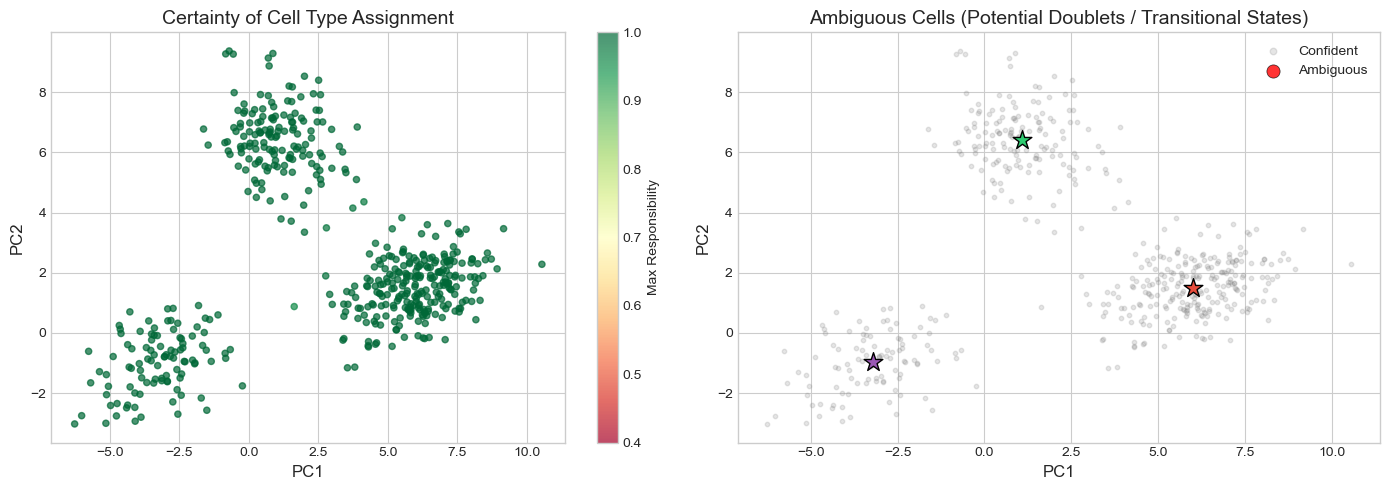


Ambiguous cells lie between clusters — they could be:
- Doublets (two cells captured in one droplet, blending expression profiles)
- Cells in a transitional differentiation state
- Flagged for quality control or further investigation with marker genes


In [13]:
# Find cells with high uncertainty (no dominant type)
max_responsibility = R_est.max(axis=1)
uncertain_mask = max_responsibility < 0.7  # Less than 70% confident

print(f"Cells with uncertain type assignment (<70% confidence): {uncertain_mask.sum()}")
print(f"Percentage of ambiguous cells: {uncertain_mask.sum()/N:.1%}")

# Visualize uncertainty
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Color by certainty
scatter = axes[0].scatter(Y[:, 0], Y[:, 1], c=max_responsibility, cmap='RdYlGn', 
                          s=20, alpha=0.7, vmin=0.4, vmax=1.0)
plt.colorbar(scatter, ax=axes[0], label='Max Responsibility')
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].set_title('Certainty of Cell Type Assignment', fontsize=14)

# Right: Highlight uncertain cells
certain_mask = ~uncertain_mask
axes[1].scatter(Y[certain_mask, 0], Y[certain_mask, 1], c='gray', alpha=0.2, s=10, label='Confident')
axes[1].scatter(Y[uncertain_mask, 0], Y[uncertain_mask, 1], c='red', alpha=0.8, s=40, 
                marker='o', edgecolors='black', linewidths=0.5, label='Ambiguous')

# Add cluster centers
for k, color in enumerate(colors):
    axes[1].scatter(*mus_est[k], s=200, marker='*', c=color, edgecolors='black', linewidths=1)

axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('Ambiguous Cells (Potential Doublets / Transitional States)', fontsize=14)
axes[1].legend(markerscale=1.5)

plt.tight_layout()
plt.show()

print("\nAmbiguous cells lie between clusters — they could be:")
print("- Doublets (two cells captured in one droplet, blending expression profiles)")
print("- Cells in a transitional differentiation state")
print("- Flagged for quality control or further investigation with marker genes")

## 9. Summary

### What We Learned

1. **Mixture Models** create complex distributions by combining simple ones:
   $$p(\mathbf{y}) = \sum_{k=1}^{K} \pi_k \, p_k(\mathbf{y})$$

2. **GMM** assumes Gaussian components, characterized by:
   - Mixing weights $\pi_k$ (cell type proportions)
   - Means $\boldsymbol{\mu}_k$ (cluster centers in PC space)
   - Covariances $\boldsymbol{\Sigma}_k$ (population spread and shape)

3. **Responsibilities** $r_{nk} = p(z_n=k|\mathbf{y}_n)$ give soft cell type assignments

4. **EM Algorithm** alternates between:
   - E-step: compute responsibilities given parameters
   - M-step: update parameters given responsibilities

5. **Biological Value**: GMM provides both cell type assignments AND uncertainty quantification — critical for identifying doublets and transitional cells in scRNA-seq

### Key Formulas from Chapter 3.5

| Concept | Formula |
|---------|--------|
| Mixture density | $p(\mathbf{y}) = \sum_{k=1}^{K} \pi_k \, p(\mathbf{y}\|\boldsymbol{\theta}_k)$ |
| GMM | $p(\mathbf{y}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{y}\|\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$ |
| Responsibility | $r_{nk} = \frac{\pi_k \mathcal{N}(\mathbf{y}_n\|\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{k'} \pi_{k'} \mathcal{N}(\mathbf{y}_n\|\boldsymbol{\mu}_{k'}, \boldsymbol{\Sigma}_{k'})}$ |
| Hard clustering | $\hat{z}_n = \arg\max_k r_{nk}$ |